# Import Libraries - 

In [43]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Load DataSet - 

In [44]:
df = pd.read_csv("loan_prediction.csv")

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

#  Data Cleaning - 

In [45]:
# Remove Loan_ID column
df.drop("Loan_ID", axis=1, inplace=True)

# Convert target variable
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

# Split Features & Target - 

In [46]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Train Test Split - 

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Identify Column Types - 

In [48]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocessing Pipeline - 

In [49]:
# Numerical pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Transform Data

In [50]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

#  Handle Class Imbalance - 

In [51]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Loan_Status
1    337
0    154
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    337
0    337
Name: count, dtype: int64


# Train Logistic Regression - 

In [52]:
model = LogisticRegression()

model.fit(X_train_smote, y_train_smote)

LogisticRegression()

# Predictions - 

In [53]:
y_pred = model.predict(X_test_processed)

y_prob = model.predict_proba(X_test_processed)[:, 1]

# Model Evaluation - 

In [54]:
print("\n===== LOGISTIC REGRESSION RESULTS =====\n")

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))


===== LOGISTIC REGRESSION RESULTS =====

Accuracy Score:
0.8211382113821138

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123


Confusion Matrix:
[[26 12]
 [10 75]]

ROC-AUC Score:
0.8758513931888545


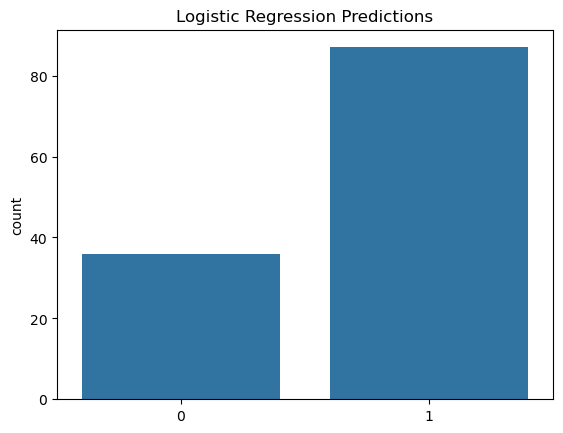

In [55]:
# =========================================
# LOGISTIC REGRESSION PREDICTIONS
# =========================================

sns.countplot(x=y_pred)

plt.title("Logistic Regression Predictions")

plt.show()

# Train Decision Tree  -


In [56]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=5, random_state=42)

# Predictions - 

In [57]:
dt_pred = dt_model.predict(X_test_processed)

dt_prob = dt_model.predict_proba(X_test_processed)[:, 1]

# Model Evaluation - 

In [58]:
print("\n===== DECISION TREE RESULTS =====\n")

print("Accuracy Score:")
print(accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, dt_prob))


===== DECISION TREE RESULTS =====

Accuracy Score:
0.7560975609756098

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57        38
           1       0.80      0.86      0.83        85

    accuracy                           0.76       123
   macro avg       0.71      0.69      0.70       123
weighted avg       0.75      0.76      0.75       123


Confusion Matrix:
[[20 18]
 [12 73]]

ROC-AUC Score:
0.7004643962848298


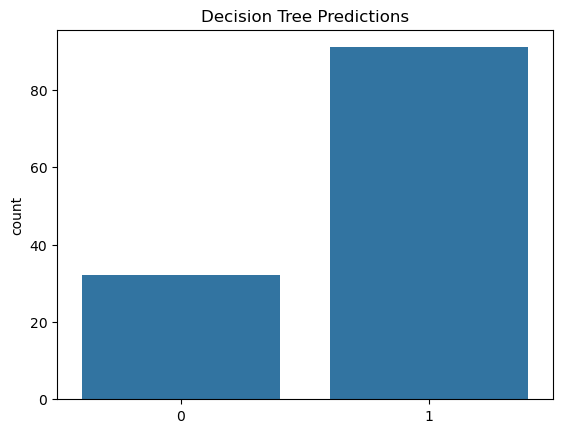

In [59]:
# =========================================
# DECISION TREE PREDICTIONS
# =========================================

sns.countplot(x=dt_pred)

plt.title("Decision Tree Predictions")

plt.show()

# Train RANDOM FOREST MODEL - 

In [60]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)


RandomForestClassifier(n_estimators=200, random_state=42)

# Predictions - 

In [61]:
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Model Evaluation - 

In [62]:
print("\n===== RANDOM FOREST RESULTS =====\n")

print("Accuracy Score:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, rf_prob))


===== RANDOM FOREST RESULTS =====

Accuracy Score:
0.7967479674796748

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.61      0.65        38
           1       0.83      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.74      0.75       123
weighted avg       0.79      0.80      0.79       123


Confusion Matrix:
[[23 15]
 [10 75]]

ROC-AUC Score:
0.7876160990712074


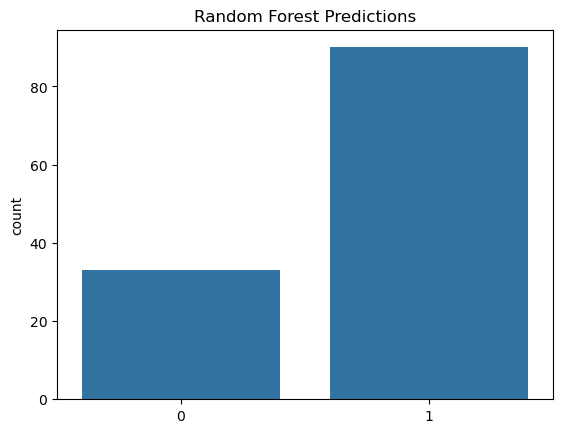

In [63]:
# =========================================
# RANDOM FOREST PREDICTIONS
# =========================================

sns.countplot(x=rf_pred)

plt.title("Random Forest Predictions")

plt.show()

# Feature Importance - 

In [64]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop Important Features:\n")
print(coefficients.head(10))


Top Important Features:

                         Feature  Coefficient
4            num__Credit_History     1.264772
18  cat__Property_Area_Semiurban     0.485655
11             cat__Dependents_2     0.276412
13       cat__Education_Graduate     0.176153
0           num__ApplicantIncome     0.144487
8               cat__Married_Yes     0.143198
12            cat__Dependents_3+     0.132878
5             cat__Gender_Female     0.074236
15         cat__Self_Employed_No     0.025427
3          num__Loan_Amount_Term    -0.015256


# MODEL COMPARISON - 

In [65]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Precision": [

        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )["1"]["precision"],

        classification_report(
            y_test,
            dt_pred,
            output_dict=True
        )["1"]["precision"],

        classification_report(
            y_test,
            rf_pred,
            output_dict=True
        )["1"]["precision"]
    ],

    "Recall": [

        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )["1"]["recall"],

        classification_report(
            y_test,
            dt_pred,
            output_dict=True
        )["1"]["recall"],

        classification_report(
            y_test,
            rf_pred,
            output_dict=True
        )["1"]["recall"]
    ],

    "F1-Score": [

        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )["1"]["f1-score"],

        classification_report(
            y_test,
            dt_pred,
            output_dict=True
        )["1"]["f1-score"],

        classification_report(
            y_test,
            rf_pred,
            output_dict=True
        )["1"]["f1-score"]
    ],

    "ROC-AUC": [

        roc_auc_score(y_test, y_prob),

        roc_auc_score(y_test, dt_prob),

        roc_auc_score(y_test, rf_prob)
    ]
})

print("\n===== MODEL COMPARISON =====\n")

print(results)


===== MODEL COMPARISON =====

                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.862069  0.882353  0.872093  0.875851
1        Decision Tree   0.802198  0.858824  0.829545  0.700464
2        Random Forest   0.833333  0.882353  0.857143  0.787616


# Class Distribution - 

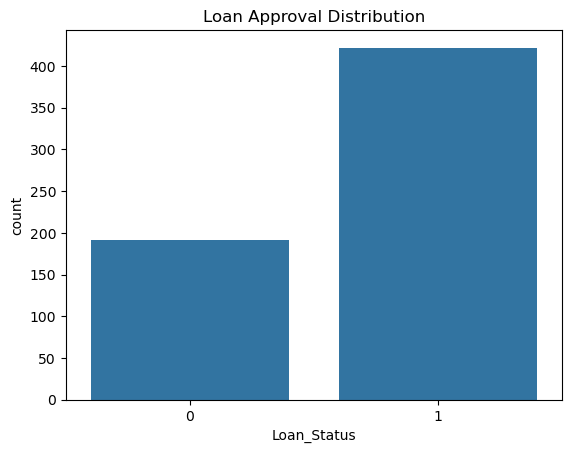

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Loan Approval Distribution")

plt.show()

# Model Comparison Chart - 

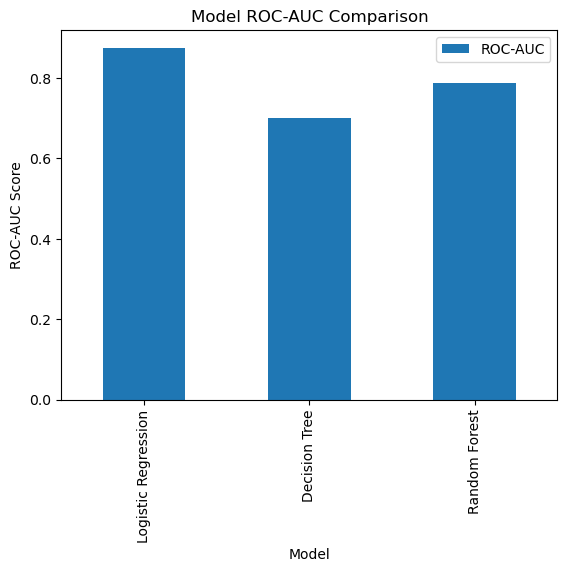

In [67]:
results.plot(
    x="Model",
    y="ROC-AUC",
    kind="bar"
)

plt.title("Model ROC-AUC Comparison")

plt.ylabel("ROC-AUC Score")

plt.show()

# Business Interpretation

- Applicants with strong credit history are more likely to receive loan approval.
- Higher applicant income positively impacts approval probability.
- Lower loan amount and balanced debt ratio reduce lending risk.
- Logistic Regression provides better interpretability for financial institutions.
- Random Forest captures complex relationships and improves prediction accuracy.

## Suggested Deployment Threshold

Instead of the default threshold of 0.50, banks can use 0.60 to reduce risky loan approvals and minimize default probability.

# Conclusion

This project successfully developed a supervised machine learning pipeline for loan approval prediction.

Data preprocessing, encoding, scaling, and SMOTE balancing improved model performance significantly.

Among the compared models:
- Logistic Regression provided strong interpretability and stable performance.
- Random Forest achieved competitive predictive performance.
- Decision Tree was easier to visualize but less robust.

Based on interpretability and ROC-AUC performance, Logistic Regression was selected as the preferred deployment model.